Nombre: David Díaz Paz y Puente | Mat: 650794

---
# A2.2 LDA y árboles de decisión

## 1. Introducción

Retomando el ejercicio de la caracterización de familias en estratos socioeconómicos (1: _Bajo_, 2: _Medio bajo_, 3: _Medio alto_, 4: _Alto_) de acuerdo a las características de vivienda recopiladas por la encuesta _Encuesta Nacional de Ingresos y Gastos de los Hogares_ (ENIGH) 2024 en Nuevo León, en esta práctica se resolverá el problema de clasificación mediante el desarrollo de 2 modelos distintos basados en _Linear Discriminant Analysis_ (LDA) y _árboles de decisiones_, respectivamente. Esto se realizará con la finalidad de analizar y comparar cuál de ambos modelos resulta más adecuado para resolver el problema planteado.

---

## 2. Definición del problema y descripción de los datos

### 2.1 Variable de salida

La variable de salida para este estudio será una modificación de la variable anterior (`est_socio`), ya que en lugar de contener 4 clases pasará a ser representada de 3 maneras: _Bajo_, _Medio_ y _Alto_. Para esto se fusionaron las observaciones resultantes de las clases _Medio alto_ y _Alto_, anteriormente utilizadas. Esto será realizado para simplificar la visualización gráfica de salida del algoritmo y reducir redundancia debido a la baja cantidad de observaciones que representan ambas clases (_Medio alto_ y _Alto_).

### 2.2 Descripción del dataset

In [15]:
import pandas as pd
df = pd.read_csv(r'features_lasso.csv')

print("Observaciones: \t\t", df.shape[0])
print("Variables (Método Lasso): \t", df.shape[1], "\n")
print(f"Total NA: {int(df.isnull().sum().sum())}")

Observaciones: 		 3767
Variables (Método Lasso): 	 45 

Total NA: 0


### 2.3 Balance de clases

In [16]:
# Balance de clases
balance = (
    df['est_socio']
    .value_counts()
    .sort_index()
    .rename_axis("Clase")
    .reset_index(name="Observaciones")
)

balance["Proporcion (%)"] = (balance["Observaciones"] / len(df) * 100).round(2)

print(balance.to_string(index=False))

 Clase  Observaciones  Proporcion (%)
     1            368            9.77
     2           2136           56.70
     3            744           19.75
     4            519           13.78


Con base en el balance de clases observado, el dataset no está balanceado: la clase 2 concentra la mayoría de las observaciones (56.70%), mientras que la clase 1 es claramente minoritaria con solo 9.77%. Las clases 3 (19.75%) y 4 (13.78%) se encuentran en un punto intermedio, pero siguen estando por debajo de la clase dominante. Esta distribución implica que el modelo, de no ser tratado adecuadamente, pudiera tender a favorecer predicciones de la clase 2. 

Esto hace más importante conservar el balance entre clases al momento de generar las particiones para entrenamiento y prueba. Por que de no conservar el balance adecuadamente, por ejemplo, puede resultar un _accuracy_ aparentemente alto solo por predecir la clase mayoritaria, pero un desempeño pobre en clases minoritarias que también importan, especialmente en el contexto de estudios diagnósticos socioeconómicos.

In [17]:
# Fusionar clases
df['est_socio'] = df['est_socio'].replace({
    4: 3  # Alta -> Alto
})

# Diccionario de etiquetas para interpretación
labels = {
    1: "Bajo",
    2: "Media",
    3: "Alto"
}

# Verificación del nuevo balance de clases
balance = (
    df['est_socio']
    .value_counts()
    .sort_index()
    .rename_axis("Clase")
    .reset_index(name="Observaciones")
)

balance["Clase_nombre"] = balance["Clase"].map(labels)
balance["Proporcion (%)"] = (balance["Observaciones"] / len(df) * 100).round(2)

print(balance[["Clase","Clase_nombre","Observaciones","Proporcion (%)"]].to_string(index=False))

 Clase Clase_nombre  Observaciones  Proporcion (%)
     1         Bajo            368            9.77
     2        Media           2136           56.70
     3         Alto           1263           33.53


Por útlimo, con la finalidad de reducir el número de clases a 3, se realizó la fusión de datos para la clase _Media alta_ y _Alta_, y se realizó (conceptualmente) el cambio de identidad de _Media baja_ a _Media_.

---

## 3. Partición de los datos

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop('est_socio', axis=1)
y = df['est_socio']

x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

El conjunto de datos se dividió en subconjuntos de entrenamiento (80%) y prueba (20%) mediante un muestreo estratificado. Tal como se mencionó en la práctica previa, la estratificación asegura que se preserven las proporciones originales de las clases en cada una de las particiones generadas.

A continuación, se separaron los dos modelos de clasificación para el mismo problema: uno basado en LDA y otro basado en árboles de decisión. 

---

## 4. Modelo basado en LDA

### 4.1 Descripción del método

| Elemento Bayes | Interpretación en el problema |
|---|---|
| Hipótesis \(H\) | Clase socioeconómica del hogar (Bajo, Medio, Alto). |
| Prior \(P(H)\) | Proporción de cada clase en el dataset, que representa la probabilidad inicial de que un hogar pertenezca a cada nivel socioeconómico antes de observar sus características. |
| Evidencia \(X\) | Conjunto de variables observadas que describen las características del hogar (por ejemplo, condiciones de vivienda o indicadores socioeconómicos). |
| Likelihood \(P(X \mid H)\) | Probabilidad de observar esas características del hogar suponiendo que pertenece a una clase socioeconómica específica. |
| Posterior \(P(H \mid X)\) | Probabilidad final de que un hogar pertenezca a una clase socioeconómica determinada dadas sus características observadas. |

En el modelo LDA, el problema de clasificación puede interpretarse desde el teorema de Bayes. Las hipótesis corresponden a las posibles clases socioeconómicas (_Bajo_, _Medio_ y _Alto_), mientras que la evidencia está formada por el conjunto de variables observadas que describen las características del hogar. Las probabilidades a priori se estiman a partir de la proporción de cada clase en el conjunto de datos, reflejando la frecuencia relativa de cada nivel socioeconómico. El likelihood representa la probabilidad de observar dichas características dado que el hogar pertenece a una clase específica, asumiendo una distribución normal multivariada para cada clase. Finalmente, el modelo calcula la probabilidad posterior de pertenecer a cada clase y asigna la observación a aquella con mayor probabilidad.

### 4.2 Entrenamiento del modelo

En el caso de LDA, se construye un pipeline que primero aplica un escalamiento estándar a las variables (centrarlas y normalizarlas) y luego entrena el clasificador Linear Discriminant Analysis, lo cual es importante porque LDA puede verse afectado por diferencias de escala entre variables.

In [19]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Pipeline LDA
lda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearDiscriminantAnalysis())
])

# CV estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "f1_macro", "f1_weighted"]
lda_cv = cross_validate(
    lda_pipe, x_train, y_train,
    cv=cv, scoring=scoring,
    return_train_score=True
)

print("Validación cruzada [LDA] (5-fold) - Promedios")
print(f"TRAIN Accuracy (mean±std):    {lda_cv['train_accuracy'].mean():.4f} ± {lda_cv['train_accuracy'].std():.4f}")
print(f"TRAIN F1-Macro (mean±std):    {lda_cv['train_f1_macro'].mean():.4f} ± {lda_cv['train_f1_macro'].std():.4f}")
print(f"TRAIN F1-Weighted (mean±std): {lda_cv['train_f1_weighted'].mean():.4f} ± {lda_cv['train_f1_weighted'].std():.4f}")

print(f"VAL   Accuracy (mean±std):    {lda_cv['test_accuracy'].mean():.4f} ± {lda_cv['test_accuracy'].std():.4f}")
print(f"VAL   F1-Macro (mean±std):    {lda_cv['test_f1_macro'].mean():.4f} ± {lda_cv['test_f1_macro'].std():.4f}")
print(f"VAL   F1-Weighted (mean±std): {lda_cv['test_f1_weighted'].mean():.4f} ± {lda_cv['test_f1_weighted'].std():.4f}")

y_train_pred = cross_val_predict(lda_pipe, x_train, y_train, cv=cv)
categorias = ["Bajo", "Medio", "Alto"]  # ajusta si tus clases/labels cambian

# Entrenamiento en train
lda_pipe.fit(x_train, y_train)

Validación cruzada [LDA] (5-fold) - Promedios
TRAIN Accuracy (mean±std):    0.7704 ± 0.0038
TRAIN F1-Macro (mean±std):    0.7411 ± 0.0067
TRAIN F1-Weighted (mean±std): 0.7709 ± 0.0039
VAL   Accuracy (mean±std):    0.7634 ± 0.0104
VAL   F1-Macro (mean±std):    0.7303 ± 0.0136
VAL   F1-Weighted (mean±std): 0.7636 ± 0.0105


,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None


El modelo basado en LDA sí encuentra diferencias útiles entre las clases, pero la separación lineal no es perfecta. Aunque el accuracy y el F1-weighted se ven bien en general, el F1-macro más bajo indica que no todas las clases se están clasificando igual de bien. En otras palabras, una o más clases presentan dificultades de discriminación y su desempeño inferior reduce el promedio macro, aun cuando las clases más frecuentes sostienen un buen resultado global. 

### 4.3 Visualización de funciones discriminantes

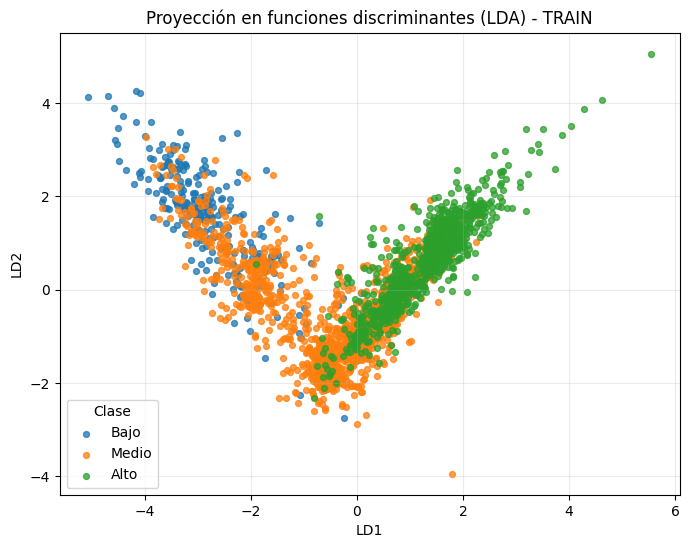

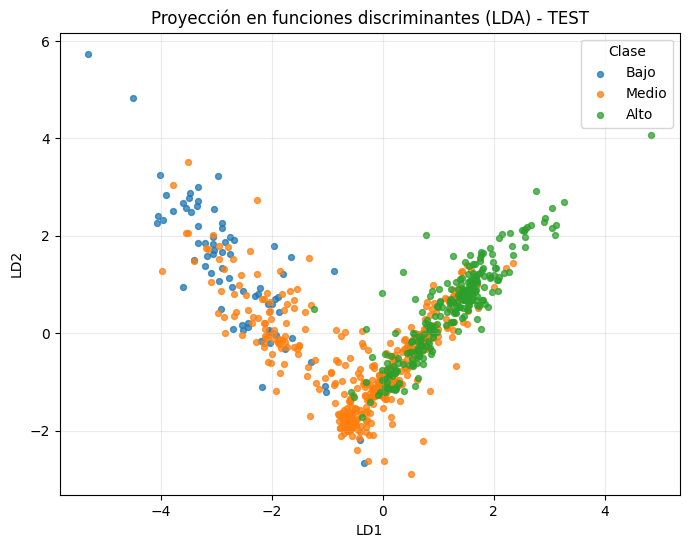

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Extraer scaler y modelo LDA del pipeline ya entrenado
scaler = lda_pipe.named_steps["scaler"]
lda_model = lda_pipe.named_steps["model"]

# Proyectar a espacio discriminante (train y test)
X_train_scaled = scaler.transform(x_train)
X_test_scaled  = scaler.transform(x_test)

Z_train = lda_model.transform(X_train_scaled)
Z_test  = lda_model.transform(X_test_scaled)

# Etiquetas legibles (ajusta si cambias nombres)
label_map = {1: "Bajo", 2: "Medio", 3: "Alto"}
y_train_lbl = y_train.map(label_map) if hasattr(y_train, "map") else np.vectorize(label_map.get)(y_train)
y_test_lbl  = y_test.map(label_map) if hasattr(y_test, "map") else np.vectorize(label_map.get)(y_test)

# Caso típico con 3 clases: 2 discriminantes (LD1 y LD2)
if Z_train.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(8, 6))
    for cls in ["Bajo", "Medio", "Alto"]:
        m = (y_train_lbl == cls)
        ax.scatter(Z_train[m, 0], Z_train[m, 1], s=18, alpha=0.75, label=cls)

    ax.set_title("Proyección en funciones discriminantes (LDA) - TRAIN")
    ax.set_xlabel("LD1")
    ax.set_ylabel("LD2")
    ax.legend(title="Clase", loc="best")
    ax.grid(True, alpha=0.25)
    plt.show()

    # (Opcional) repetir en TEST para ver generalización geométrica
    fig, ax = plt.subplots(figsize=(8, 6))
    for cls in ["Bajo", "Medio", "Alto"]:
        m = (y_test_lbl == cls)
        ax.scatter(Z_test[m, 0], Z_test[m, 1], s=18, alpha=0.75, label=cls)

    ax.set_title("Proyección en funciones discriminantes (LDA) - TEST")
    ax.set_xlabel("LD1")
    ax.set_ylabel("LD2")
    ax.legend(title="Clase", loc="best")
    ax.grid(True, alpha=0.25)
    plt.show()

else:
    # Si por alguna razón solo hay 1 discriminante, graficamos LD1 como distribución
    fig, ax = plt.subplots(figsize=(8, 4))
    for cls in ["Bajo", "Medio", "Alto"]:
        m = (y_train_lbl == cls)
        ax.hist(Z_train[m, 0], bins=30, alpha=0.5, label=cls)
    ax.set_title("Distribución de LD1 (LDA) - TRAIN")
    ax.set_xlabel("LD1")
    ax.set_ylabel("Frecuencia")
    ax.legend(title="Clase", loc="best")
    ax.grid(True, alpha=0.25)
    plt.show()

Las gráficas proyectan las observaciones sobre las dos funciones discriminantes en los conjuntos de entrenamiento y prueba. En ambas se aprecia una estructura en forma de "V", lo que indica que LD1 y LD2 actúan de forma conjunta para separar las clases.

La clase Bajo se concentra en la región superior izquierda (LD1 negativo, LD2 alto), mientras que Alto forma un núcleo compacto y bien definido hacia la derecha (LD1 positivo), lo que refleja que los hogares de estrato alto presentan características de vivienda homogéneas y fácilmente distinguibles. La clase Medio se dispersa por el centro e inferior del espacio, solapándose con ambas clases en distintas zonas, siendo la principal fuente de error del modelo (como se mencionó en el punto anterior).

La proyección TEST replica fielmente esta estructura, confirmando que las funciones discriminantes aprendidas generalizan correctamente y no son producto de sobreajuste. Los patrones de separación y solapamiento se mantienen consistentes entre ambas particiones.

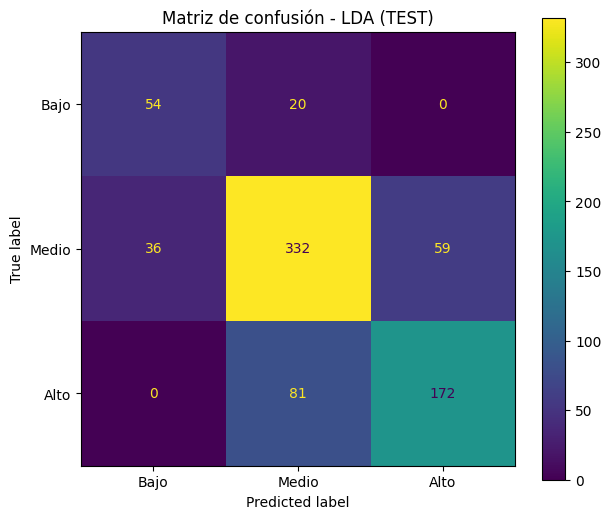

In [50]:
y_pred_test = lda_pipe.predict(x_test)

# Si y_test es 1/2/3 -> convertimos a labels para alinear con display_labels
y_pred_test_lbl = (
    pd.Series(y_pred_test).map(label_map).values
    if "pd" in globals()
    else np.vectorize(label_map.get)(y_pred_test)
)

# Orden consistente de clases
display_labels = ["Bajo", "Medio", "Alto"]

cm_test = confusion_matrix(y_test_lbl, y_pred_test_lbl, labels=display_labels)

fig, ax_LDA = plt.subplots(figsize=(7, 6))
disp_LDA = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=display_labels)
disp_LDA.plot(ax=ax_LDA, values_format="d")
ax_LDA.set_title("Matriz de confusión - LDA (TEST)")
plt.show()

La matriz de confusión confirma el problema: muchos casos _Bajo_ y _Alto_ terminan predichéndose como _Medio_. Eso implica falsos negativos para _Bajo_/_Alto_ y, al mismo tiempo, falsos positivos para _Medio_. 

---

## 5. Modelo basado en Árbol de Decisión

### 5.1 Descripción del método

Para el desarrollo de este ejercicio utilizaremos la función ``DecisionTreeClassifier`` de la librería ``sklearn``, la cual nos permitirá generar una instancia de un clasificador basado en árboles de decisión, preparada para ser entrenada con el dataset disponible. En términos prácticos, esta función crea un modelo que posteriormente podrá aprender patrones a partir de las variables de entrada y de la variable objetivo, con el fin de clasificar nuevas observaciones de acuerdo con las reglas que vaya construyendo durante el entrenamiento. Dichas reglas se generan mediante divisiones sucesivas de los datos, donde en cada nodo del árbol se selecciona la característica y el umbral que mejor separan las clases según un criterio de impureza, como puede ser el índice Gini o la entropía.

### 5.2 Entrenamiento del modelo

In [49]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

base_tree_no_limit = DecisionTreeClassifier(criterion="gini", random_state=42, class_weight="balanced")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = cross_validate(
    base_tree_no_limit,
    x_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "f1_macro", "f1_weighted"],
    return_train_score=True
)

print("Validación cruzada [Árbol de decisión] (5-fold) - Promedios")
print(f"TRAIN Accuracy (mean±std):    {resultados['train_accuracy'].mean():.4f} ± {resultados['train_accuracy'].std():.4f}")
print(f"TRAIN F1-Macro (mean±std):    {resultados['train_f1_macro'].mean():.4f} ± {resultados['train_f1_macro'].std():.4f}")
print(f"TRAIN F1-Weighted (mean±std): {resultados['train_f1_weighted'].mean():.4f} ± {resultados['train_f1_weighted'].std():.4f}")

print(f"VAL   Accuracy (mean±std):    {resultados['test_accuracy'].mean():.4f} ± {resultados['test_accuracy'].std():.4f}")
print(f"VAL   F1-Macro (mean±std):    {resultados['test_f1_macro'].mean():.4f} ± {resultados['test_f1_macro'].std():.4f}")
print(f"VAL   F1-Weighted (mean±std): {resultados['test_f1_weighted'].mean():.4f} ± {resultados['test_f1_weighted'].std():.4f}")


Validación cruzada [Árbol de decisión] (5-fold) - Promedios
TRAIN Accuracy (mean±std):    0.9873 ± 0.0009
TRAIN F1-Macro (mean±std):    0.9896 ± 0.0007
TRAIN F1-Weighted (mean±std): 0.9873 ± 0.0008
VAL   Accuracy (mean±std):    0.6947 ± 0.0242
VAL   F1-Macro (mean±std):    0.6428 ± 0.0307
VAL   F1-Weighted (mean±std): 0.6945 ± 0.0231


Para el entrenamiento del modelo se utilizó la clase ``DecisionTreeClassifier`` de sklearn, empleando como criterio de división el índice Gini, ya que este permite seleccionar en cada nodo la partición que mejor reduce la impureza de las clases. Inicialmente se entrenó un árbol base sin límite de profundidad con el fin de observar su comportamiento general. Sin embargo, debido a que los árboles muy profundos tienden a ajustarse en exceso a los datos de entrenamiento, posteriormente se construyó una segunda versión del modelo con profundidad máxima de 3 niveles (``max_depth=3``), manteniendo ``random_state=42`` para asegurar la reproducibilidad de los resultados. Esta configuración permitió obtener un modelo más controlado y con menor riesgo de sobreajuste, sirviendo además como base para la etapa posterior de poda. Adicionalmente, se incorporó el parámetro class_weight="balanced" en ambas pruebas, de esta forma el modelo asigna un mayor peso a las clases menos representadas durante el entrenamiento.

In [47]:
base_tree_lim = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42, class_weight="balanced")
resultados_lim = cross_validate(
    base_tree_lim,
    x_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "f1_macro", "f1_weighted"],
    return_train_score=True
)

print("Validación cruzada [Árbol de decisión (max_depth=3)] (5-fold) - Promedios")
print(f"TRAIN Accuracy (mean±std):    {resultados_lim['train_accuracy'].mean():.4f} ± {resultados_lim['train_accuracy'].std():.4f}")
print(f"TRAIN F1-Macro (mean±std):    {resultados_lim['train_f1_macro'].mean():.4f} ± {resultados_lim['train_f1_macro'].std():.4f}")
print(f"TRAIN F1-Weighted (mean±std): {resultados_lim['train_f1_weighted'].mean():.4f} ± {resultados_lim['train_f1_weighted'].std():.4f}")

print(f"VAL   Accuracy (mean±std):    {resultados_lim['test_accuracy'].mean():.4f} ± {resultados_lim['test_accuracy'].std():.4f}")
print(f"VAL   F1-Macro (mean±std):    {resultados_lim['test_f1_macro'].mean():.4f} ± {resultados_lim['test_f1_macro'].std():.4f}")
print(f"VAL   F1-Weighted (mean±std): {resultados_lim['test_f1_weighted'].mean():.4f} ± {resultados_lim['test_f1_weighted'].std():.4f}")

Validación cruzada [Árbol de decisión (max_depth=3)] (5-fold) - Promedios
TRAIN Accuracy (mean±std):    0.7248 ± 0.0215
TRAIN F1-Macro (mean±std):    0.7040 ± 0.0167
TRAIN F1-Weighted (mean±std): 0.7268 ± 0.0248
VAL   Accuracy (mean±std):    0.7129 ± 0.0295
VAL   F1-Macro (mean±std):    0.6932 ± 0.0235
VAL   F1-Weighted (mean±std): 0.7150 ± 0.0321


### 5.3 Poda del árbol

Best alpha: 0.0024265683057462864
Best CV f1_macro: 0.6940102794992697


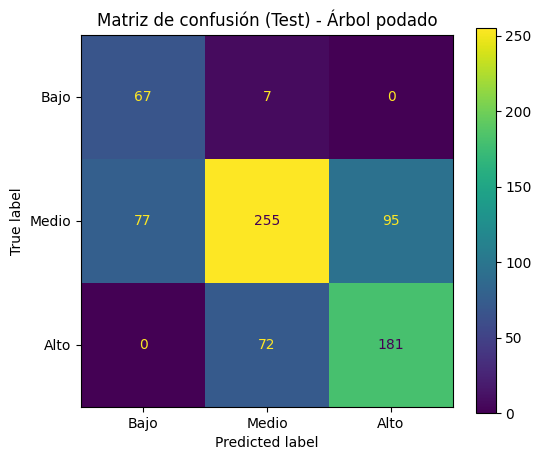

In [48]:
alphas = np.unique(base_tree_lim.cost_complexity_pruning_path(x_train, y_train).ccp_alphas)

gs = GridSearchCV(
    base_tree_lim,
    param_grid={"ccp_alpha": alphas},
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)
gs.fit(x_train, y_train)

best_tree = gs.best_estimator_
print("Best alpha:", gs.best_params_["ccp_alpha"])
print("Best CV f1_macro:", gs.best_score_)

# 3) Evaluación en test
y_pred_test = best_tree.predict(x_test)

# Matriz de confusión 
categorias = ["Bajo", "Medio", "Alto"]
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test, display_labels=categorias, ax=ax, values_format="d"
)
plt.title("Matriz de confusión (Test) - Árbol podado")
plt.show()

Una vez definido el árbol con profundidad limitada, se utilizó el método ``cost_complexity_pruning_path``, el cual busca reducir la complejidad del árbol eliminando ramas que aportan poca mejora al desempeño del modelo. Este procedimiento se controla mediante el hiperparámetro ``ccp_alpha``, donde valores más grandes producen una poda más agresiva y, por tanto, árboles más simples. 

Posteriormente, los valores seleccionados de ``ccp_alpha`` fueron evaluados mediante ``GridSearchCV``, empleando validación cruzada de 5 particiones y la métrica _f1_macro_ como criterio de selección. De esta manera, se eligió el valor de α que ofreció el mejor equilibrio entre capacidad predictiva y complejidad del modelo, dando lugar al árbol podado final. En términos prácticos, esta etapa permitió disminuir el riesgo de sobreajuste y mejorar la capacidad de generalización sobre datos no vistos.

El valor f1-macro = 0.694 indica un desempeño global aceptable del modelo, donde las clases Bajo y Alto se predicen razonablemente bien, mientras que la clase Medio presenta mayor confusión con las otras dos lo cual confirmamos con la matriz de confusión. Asimismo, existe un recall para la clase _Bajo_ de 0.91, lo cual indica que el modelo el relativamente bueno para hacer predicciones para el estrato socieconómico _Bajo_.

### 5.4 Visualización del árbol

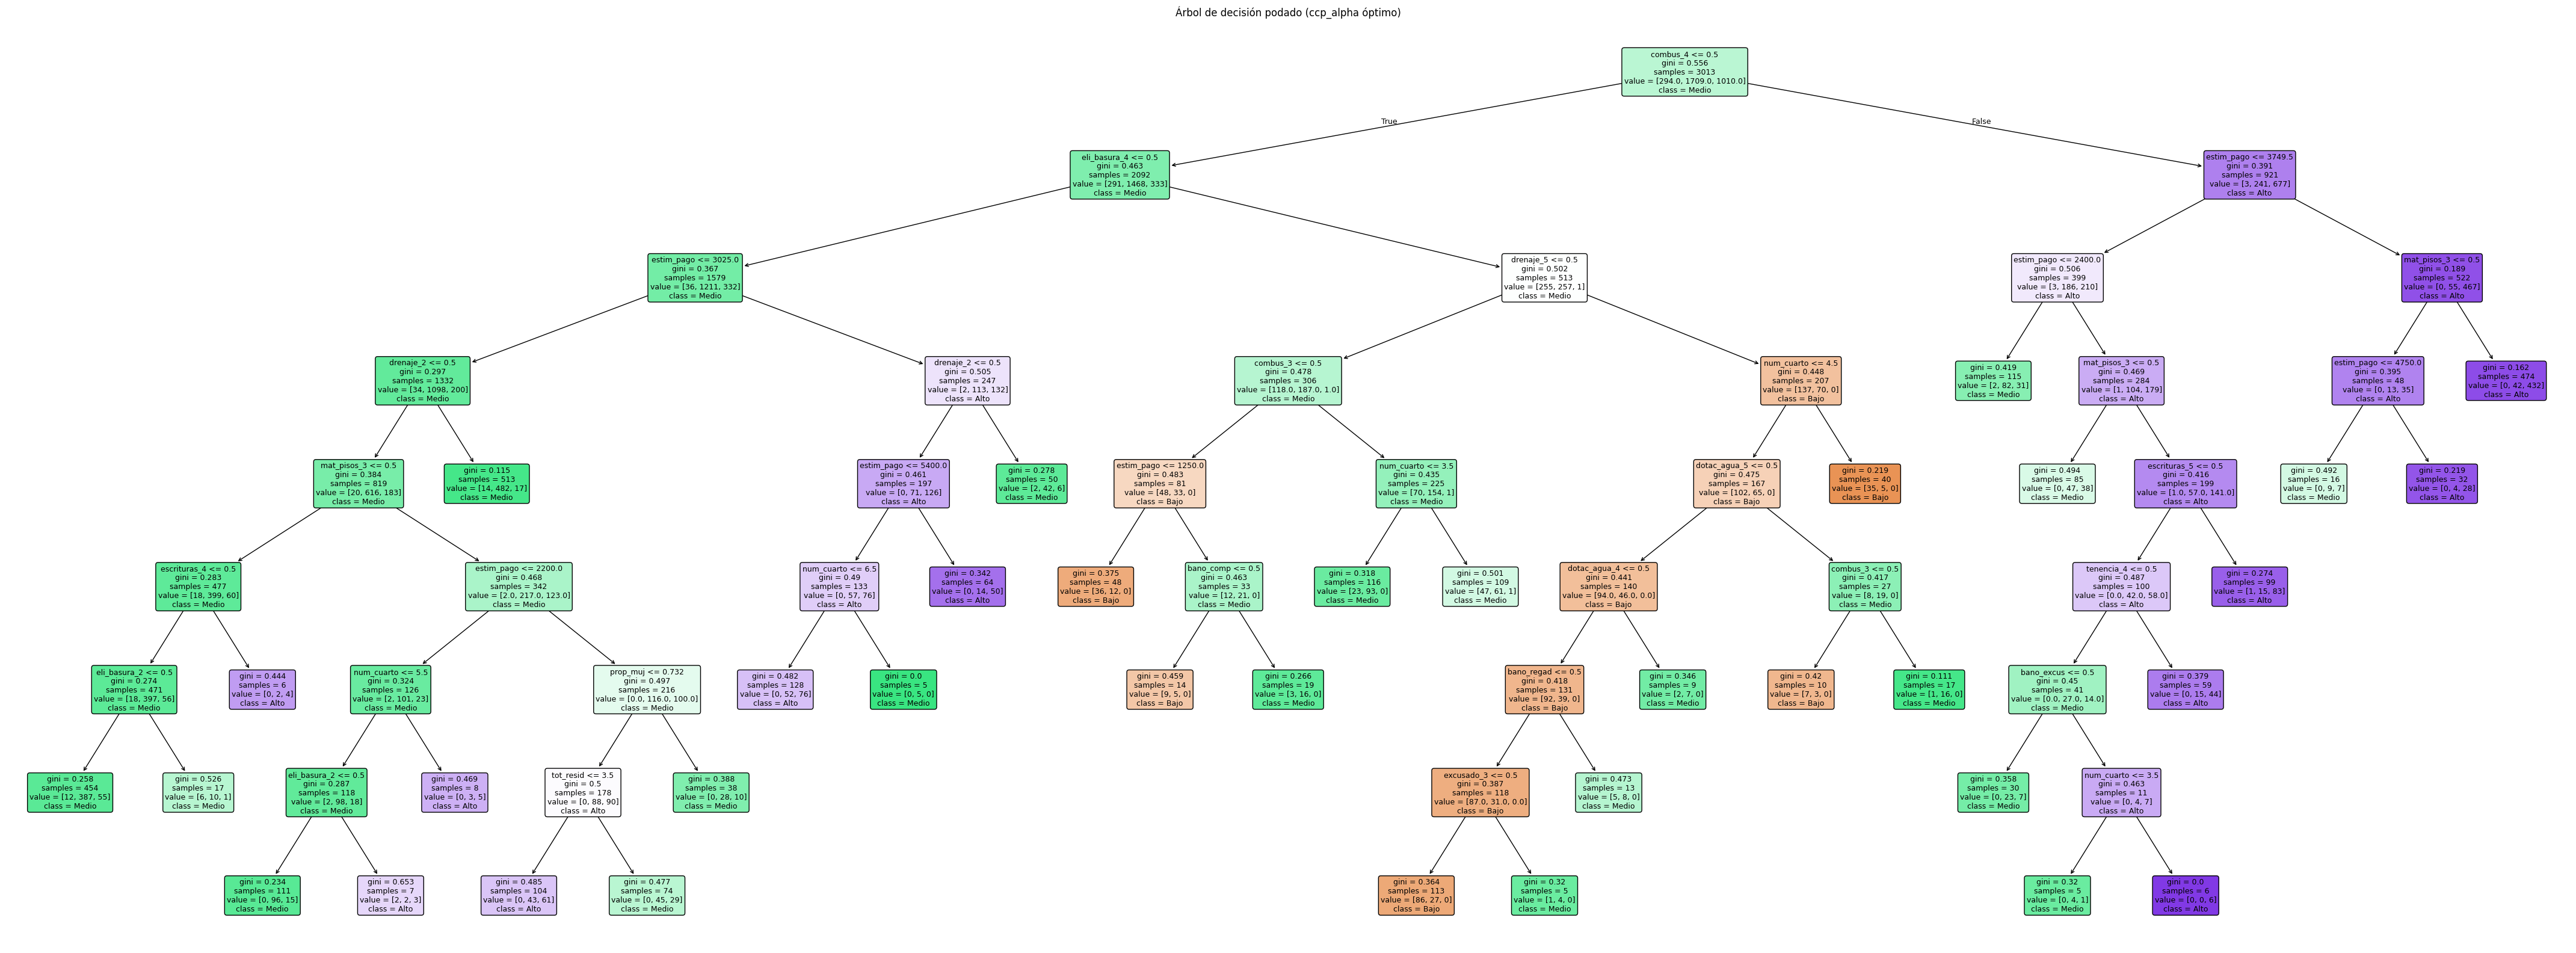

In [ ]:
plt.figure(figsize=(55, 20))
plot_tree(
    best_tree,
    feature_names=getattr(x_train, "columns", None),  
    class_names=categorias,                           
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Árbol de decisión podado (ccp_alpha óptimo)")
plt.show()

---

## 6. Comparación de los modelos

Una vez evaluados ambos modelos de clasificación, es posible seleccionar aquel que resulte más adecuado para el diagnóstico socioeconómico de familias en Nuevo León. 

El modelo basado en __LDA__ presenta un desempeño global aceptable, alcanzando un accuracy cercano al 76%, lo que indica que aproximadamente tres de cada cuatro observaciones son clasificadas correctamente. Por otra parte, la métrica F1-macro (~0.73) revela que existen dificultades para discriminar adecuadamente algunas clases, esto es confirmado en las gráficas de proyección presentadas en la sección _4.3 Visualización de funciones discriminantes_ donde existe un solapamiento entre la clase _Media_ con las clases _Bajo_ y _Alto_. Finalmente, la matriz de confusión respectiva a este modelo muestra una precisión del ~73% (proporción de predicciones positivas que fueron correctas) para la clase de interés: _Bajo_.

Por otro lado, el modelo basado en __árbol de decisión__ mostró inicialmente problemas de sobreajuste, ya que alcanzó métricas casi perfectas en entrenamiento pero disminuyó de forma importante en validación. Posteriormente se limitó la profundidad del árbol y se aplicó una poda por complejidad de costo, lo que en consecuencia hizo que el modelo se volviera más estable, alcanzando un F1-macro de validación cercano a 70%, y  aunque este valor es inferior al de LDA a nivel global, el árbol presenta una ventaja importante: mejora la capacidad predictiva sobre la clase _Bajo_, que es justamente la categoría minoritaria y más difícil de identificar.

Esta diferencia es relevante (pero no perfecta) porque, en este problema de diagnóstico socioeconómico, estamos priorizando la categorización correcta de familias en un estrato socioeconómico _Bajo_. Por ello, el árbol resulta más útil para identificar familias en condición socioeconómica baja con un 90% de precisión. 

---

## 7. Conclusión

En este trabajo se construyeron y evaluaron dos modelos de clasificación para predecir el estrato socioeconómico de familias en Nuevo León a partir de variables seleccionadas previamente mediante LASSO. El análisis mostró que el problema no solo exige un buen desempeño global, sino también una atención especial al desbalance de clases, ya que la categoría _Bajo_ representa la proporción más pequeña del conjunto de datos y, al mismo tiempo, una de las más importantes desde el punto de vista del diagnóstico social.

El modelo LDA mostró un comportamiento sólido en términos generales, con mejores métricas globales de accuracy y F1-macro. Sin embargo, suponer fronteras lineales entre clases limitó su capacidad para separar completamente los estratos, especialmente cuando la clase _Bajo_ se traslapa con la clase _Medio_. Por su parte, el árbol de decisión permitió capturar relaciones no lineales entre variables. Aunque su desempeño agregado fue ligeramente inferior, después de controlar el sobreajuste mediante restricción de profundidad y poda, demostró ser más conveniente para reconocer la clase _Bajo_.

En consecuencia, se concluye que el árbol de decisión podado es la alternativa más adecuada para este ejercicio, ya que responde mejor al objetivo práctico del problema: identificar con mayor efectividad a las familias ubicadas en el estrato socioeconómico bajo. Como trabajo futuro, podría explorarse el uso de métodos de ensamble, técnicas de rebalanceo de clases o ajuste de umbrales de decisión, con la finalidad de conservar esa ventaja sobre la clase minoritaria y, al mismo tiempo, elevar el desempeño global del modelo.